## Loading the database

# Training the Segmentation Models

In [1]:
import os
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import numpy as np

IMG_SIZE = 512
BATCH_SIZE = 8
NUM_CLASSES = 1
CROP = "wheat"  # "wheat" or "sorghum"

dataset_path = f"../data/{CROP}/"

# --- Custom Dataset for Segmentation ---
class SegmentationDataset(Dataset):
    def __init__(self, root_dir, train=True):
        self.root_dir = root_dir
        self.train = train
        self.img_dir = os.path.join(root_dir, "train/images" if train else "test/images")
        self.mask_dir = os.path.join(root_dir, "train/masks" if train else "test/masks")

        self.image_files = sorted([
            f for f in os.listdir(self.img_dir)
            if f.lower().endswith(('.png', '.jpg', '.jpeg'))
        ])
        self.mask_files = sorted([
            f for f in os.listdir(self.mask_dir)
            if f.lower().endswith(('.png', '.jpg', '.jpeg'))
        ])

        assert len(self.image_files) == len(self.mask_files), \
            f"Image/Mask count mismatch: {len(self.image_files)} vs {len(self.mask_files)}"

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.image_files[idx])
        mask_path = os.path.join(self.mask_dir, self.mask_files[idx])

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")  # grayscale mask

        # --- To Tensor ---
        image = TF.to_tensor(image)
        image = TF.normalize(image, mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])

        # Mask → tensor (no normalization)
        mask = torch.from_numpy(np.array(mask)).float().unsqueeze(0)  # [1, H, W]
        mask = (mask > 0).float()

        return image, mask

# --- Datasets & Loaders ---
train_dataset = SegmentationDataset(dataset_path, train=True)
test_dataset = SegmentationDataset(dataset_path, train=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"✅ Train size: {len(train_dataset)} | Test size: {len(test_dataset)}")

✅ Train size: 8334 | Test size: 3552


In [2]:
for i in range(3):
    img, mask = train_dataset[i]
    print(img.shape, mask.shape)

torch.Size([3, 512, 512]) torch.Size([1, 512, 512])
torch.Size([3, 512, 512]) torch.Size([1, 512, 512])
torch.Size([3, 512, 512]) torch.Size([1, 512, 512])


## Importing Models

In [2]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


### UNET

In [4]:
import sys
sys.path.append('../')
from utils.models.uNet import UNet

channels = [32, 64, 128, 256, 512]
model = UNet(in_channels=3, out_channels=1, channels=channels, bilinear=True, use_batchnorm=True)
model.to(device)
modelName = "U-NET"

### DeepLabv3+

In [3]:
import sys
sys.path.append('../')
from utils.models.deeplabv3p import DeepLabV3Plus

model = DeepLabV3Plus(num_classes=1, output_stride=16, backbone_width_mult=1.0).to(device)
model.to(device)
modelName = "DeepLabV3Plus"

### SegFormer

In [3]:
import sys
sys.path.append('../')
from utils.models.SegFormer import segformer

model = segformer(in_channels = 3, num_classes = 1)
model.to(device)
modelName = "SegFormer"

c:\Users\gnoceras\Documents\SegmentationStudy\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\gnoceras\Documents\SegmentationStudy\.venv\lib\site-packages\timm\models\layers\__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


### General Info

In [4]:
print(model)
num_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {num_params:,}")

segformer(
  (backbone): mix_transformer(
    (stages): ModuleList(
      (0): mix_transformer_stage(
        (patch_embed): overlap_patch_embed(
          (proj): Conv2d(3, 32, kernel_size=(7, 7), stride=(4, 4), padding=(3, 3))
          (norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        )
        (blocks): ModuleList(
          (0-1): 2 x transformer_block(
            (attn): efficient_self_attention(
              (sr): Conv2d(32, 32, kernel_size=(8, 8), stride=(8, 8))
              (norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
              (q): Linear(in_features=32, out_features=32, bias=True)
              (kv): Linear(in_features=32, out_features=64, bias=True)
              (proj): Linear(in_features=32, out_features=32, bias=True)
            )
            (ffn): mix_feedforward(
              (fc1): Linear(in_features=32, out_features=128, bias=True)
              (fc2): Linear(in_features=128, out_features=32, bias=True)
              (conv

## Training

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import os
from tqdm import tqdm
import matplotlib.pyplot as plt

In [5]:
# --- Configuration ---
EPOCHS = 200
early_stopping_patience = 5
best_val_loss = float('inf') 
patience_counter = 0
scaler = torch.amp.GradScaler('cuda')
# --- Loss & Optimizer ---
loss_fn = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
lr_scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

checkpoint_path = os.path.join("../models/", CROP + "_" + modelName + "_seg.pt")
print(f"Model checkpoints will be saved to: {checkpoint_path}")

# --- Tracking ---
train_losses, val_losses = [], []

Model checkpoints will be saved to: ../models/wheat_SegFormer_seg.pt


In [6]:
# --- Training Loop ---
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    with tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", unit="batch") as tepoch:
        for inputs, labels in tepoch:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            with torch.cuda.amp.autocast():
                outputs = model(inputs)
                if torch.isnan(outputs).any() or torch.isinf(outputs).any():
                    print("NaN or Inf in model outputs!")
                if torch.isnan(labels).any() or torch.isinf(labels).any():
                    print("NaN or Inf in labels!")
                if labels.sum() == 0:
                    print("Skipping batch with all empty masks")
                    continue
                loss = loss_fn(outputs, labels)
            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item()
            tepoch.set_postfix(loss=running_loss / (len(tepoch)))
    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # --- Validation Phase ---
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        with tqdm(test_loader, desc=f"Epoch {epoch+1}/{EPOCHS} - Validation", unit="batch") as vepoch:
            for inputs, labels in vepoch:
                inputs, labels = inputs.to(device), labels.to(device)
                with torch.cuda.amp.autocast():
                    outputs = model(inputs)
                    if torch.isnan(outputs).any() or torch.isinf(outputs).any():
                        print("NaN or Inf in model outputs!")
                    if torch.isnan(labels).any() or torch.isinf(labels).any():
                        print("NaN or Inf in labels!")
                    if labels.sum() == 0:
                        print("Skipping batch with all empty masks")
                        continue
                    loss = loss_fn(outputs, labels)
                    preds = (torch.sigmoid(outputs) > 0.5).float()
                val_correct += (preds == labels).sum().item()
                val_total += labels.numel()
                val_acc = val_correct / val_total if val_total > 0 else 0
                val_loss += loss.item()
                vepoch.set_postfix(loss=val_loss / (len(vepoch)))

    avg_val_loss = val_loss / len(test_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1} - Val Loss: {avg_val_loss:.4f} - Val Acc: {val_acc:.4f}%")

    # --- Scheduler step (use validation loss) ---
    lr_scheduler.step(avg_val_loss)

    # --- Checkpointing ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), checkpoint_path)
        print(f"✅ Model improved (Val Loss={avg_val_loss:.3f}), saved to {checkpoint_path}")
    else:
        patience_counter += 1
        print(f"🔴 No improvement, patience counter: {patience_counter}")

    if patience_counter >= early_stopping_patience:
        print("🛑 Early stopping triggered!")
        break

Epoch 1/200:   0%|          | 0/1042 [00:00<?, ?batch/s]

C:\Users\gnoceras\AppData\Local\Temp\ipykernel_24872\458036752.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1/200 - Validation:   0%|          | 0/444 [00:00<?, ?batch/s]C:\Users\gnoceras\AppData\Local\Temp\ipykernel_24872\458036752.py:38: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1/200 - Validation: 100%|██████████| 444/444 [00:56<00:00,  7.92batch/s, loss=0.0249] 


Epoch 1 - Val Loss: 0.0249 - Val Acc: 0.9913%
✅ Model improved (Val Loss=0.025), saved to ../models/wheat_SegFormer_seg.pt


Epoch 2/200 - Validation: 100%|██████████| 444/444 [00:49<00:00,  8.94batch/s, loss=0.0166] 


Epoch 2 - Val Loss: 0.0166 - Val Acc: 0.9936%
✅ Model improved (Val Loss=0.017), saved to ../models/wheat_SegFormer_seg.pt


...

Epoch 10 - Val Loss: 0.0133 - Val Acc: 0.9950%
🔴 No improvement, patience counter: 3


Epoch 11/200 - Validation: 100%|██████████| 444/444 [00:50<00:00,  8.75batch/s, loss=0.0144] 


Epoch 11 - Val Loss: 0.0144 - Val Acc: 0.9946%
🔴 No improvement, patience counter: 4


Epoch 12/200 - Validation: 100%|██████████| 444/444 [00:49<00:00,  8.98batch/s, loss=0.0137] 

Epoch 12 - Val Loss: 0.0137 - Val Acc: 0.9951%
🔴 No improvement, patience counter: 5
🛑 Early stopping triggered!


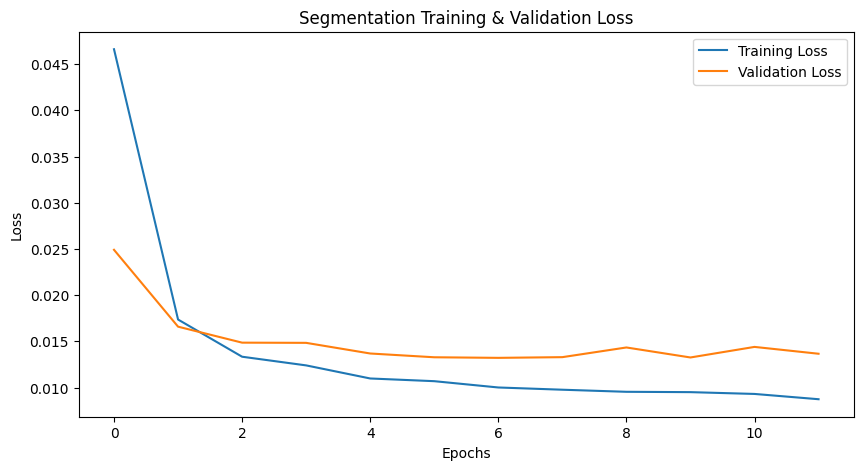

In [7]:
# --- Plot losses ---
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Segmentation Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Inference on Test Image

C:\Users\gnoceras\AppData\Local\Temp\ipykernel_24872\2977633742.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


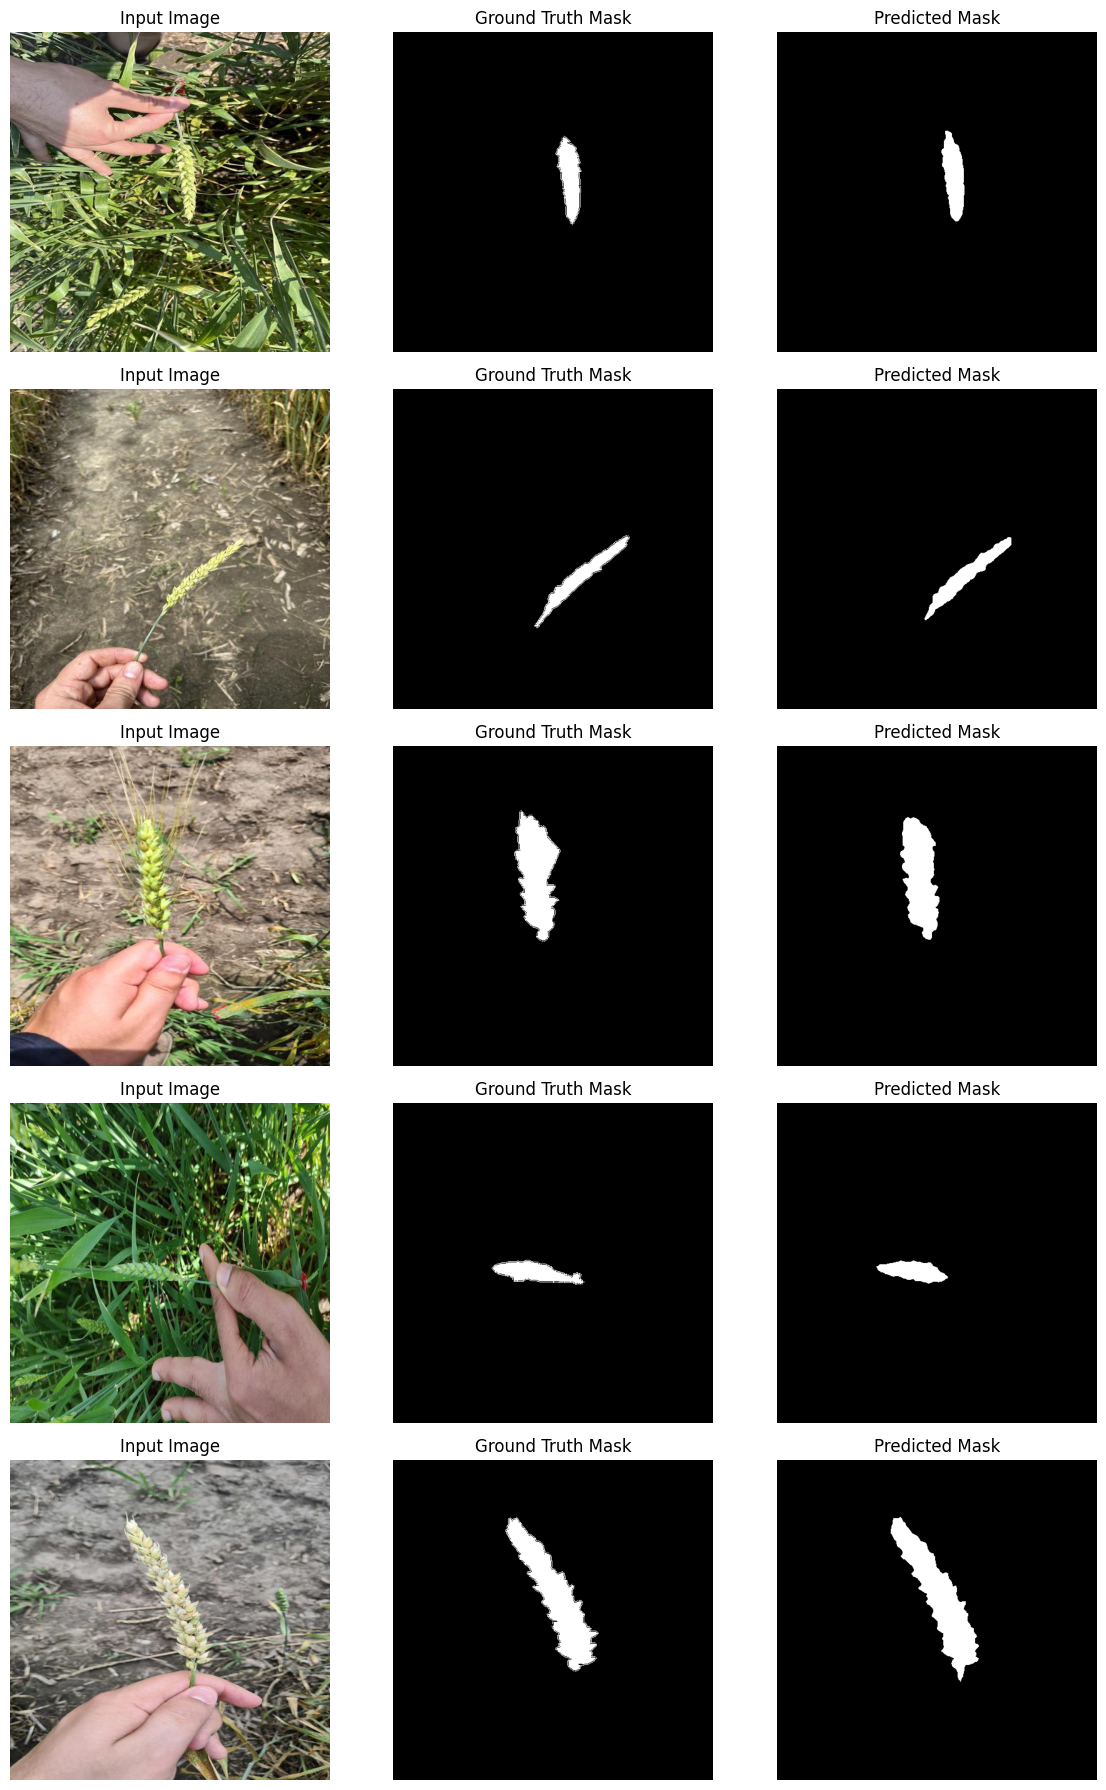

In [8]:
import random

# Pick 5 random indices from the test dataset
indices = random.sample(range(len(test_dataset)), 5)

fig, axs = plt.subplots(5, 3, figsize=(12, 18))
for i, idx in enumerate(indices):
    img, mask = test_dataset[idx]
    img_input = img.unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        with torch.cuda.amp.autocast():
            pred_logits = model(img_input)
            pred_mask = (torch.sigmoid(pred_logits) > 0.5).float().cpu().squeeze().numpy()
    axs[i, 0].imshow(img.permute(1, 2, 0).cpu() * 0.5 + 0.5)
    axs[i, 0].set_title("Input Image")
    axs[i, 1].imshow(mask.squeeze().cpu(), cmap='gray')
    axs[i, 1].set_title("Ground Truth Mask")
    axs[i, 2].imshow(pred_mask, cmap='gray')
    axs[i, 2].set_title("Predicted Mask")
    for j in range(3):
        axs[i, j].axis('off')
plt.tight_layout()
plt.show()


In [9]:
import time
from PIL import Image
import torchvision.transforms.functional as TF

# --- Config ---
IMG_PATH = "../data/{}/test/images/1_1_5.jpg".format(CROP)  # <-- set your image path

model.eval()

# --- Preprocess image ---
img = Image.open(IMG_PATH).convert("RGB")
img = img.resize((512, 512))  # resize if needed
img_tensor = TF.to_tensor(img)
img_tensor = TF.normalize(img_tensor, mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
img_tensor = img_tensor.unsqueeze(0).to(device)

# --- Inference with timing ---
with torch.no_grad():
    torch.cuda.synchronize() if torch.cuda.is_available() else None
    start = time.time()
    with torch.cuda.amp.autocast():
        pred_logits = model(img_tensor)
    torch.cuda.synchronize() if torch.cuda.is_available() else None
    end = time.time()
    pred_mask = (torch.sigmoid(pred_logits) > 0.5).float().cpu().squeeze().numpy()

print(f"Inference time: {end - start:.4f} seconds")

Inference time: 0.0817 seconds


C:\Users\gnoceras\AppData\Local\Temp\ipykernel_24872\2723461262.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
